# Nonuniform HSBM n-scaling spectral clustering

This notebook generates non-uniform HSBM hypergraphs with `generate_nonuniform_hsbm_instance`, runs spectral clustering with the Zhou normalized hypergraph Laplacian, and records misclassification rate, ARI, NMI, CPU time, wall-clock time, and memory diagnostics as `n` increases.

Each experiment cell below runs a different node count. Edit `CONFIG` or add another `df_n... = run_n_experiment(...)` cell to extend the sweep.

In [1]:
from pathlib import Path
import gc
import json
import math
import sys
import time
import tracemalloc
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

PROJECT_ROOT = Path.cwd()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / "src" / "common.py").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find project root containing src/common.py")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.common import (
    generate_nonuniform_hsbm_instance,
    make_sparse_hsbm_probs,
    normalize_rows_l2,
    zhou_normalized_laplacian,
)

EXPERIMENT_ID = "EXP-20260425-001"
EXPERIMENT_SLUG = "nonuniform_hsbm_n_scaling_zhou_laplacian"
OUTDIR = PROJECT_ROOT / "experiments" / "메인 실험" / "results" / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}"
OUTDIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

EXPERIMENT_ID, EXPERIMENT_SLUG, PROJECT_ROOT, OUTDIR

('EXP-20260425-001',
 'nonuniform_hsbm_n_scaling_zhou_laplacian',
 WindowsPath('c:/Users/WWindows10/Documents/github_project/python-rand-nla-research'),
 WindowsPath('c:/Users/WWindows10/Documents/github_project/python-rand-nla-research/experiments/메인 실험/results/EXP-20260425-001_nonuniform_hsbm_n_scaling_zhou_laplacian'))

## Configuration

`make_sparse_hsbm_probs` maps the constant-scale parameters below to `p_in[m] = a_in[m] / n ** (m - 1)` and `p_out[m] = b_out[m] / n ** (m - 1)`. This keeps the expected number of hyperedges roughly linear in `n`.

In [2]:
CONFIG = {
    "K": 3,
    "m_values": [2, 3],
    "a_in": {2: 24.0, 3: 36.0},
    "b_out": {2: 3.0, 3: 4.0},
    "reps": 10,
    "seed": 20260425,
    "sampling": "sparse",
    "max_enumeration": 1_500_000,
    "normalize_embedding_rows": True,
    "eigsh_tol": 1e-6,
}

N_VALUES = [200, 400, 800, 1200]

CONFIG, N_VALUES

({'K': 3,
  'm_values': [2, 3],
  'a_in': {2: 24.0, 3: 36.0},
  'b_out': {2: 3.0, 3: 4.0},
  'reps': 10,
  'seed': 20260425,
  'sampling': 'sparse',
  'max_enumeration': 1500000,
  'normalize_embedding_rows': True,
  'eigsh_tol': 1e-06},
 [200, 400, 800, 1200])

## Helpers

In [3]:
def current_rss_mb():
    try:
        import psutil

        return psutil.Process().memory_info().rss / (1024.0 ** 2)
    except Exception:
        return np.nan


def measure_call(fn):
    gc.collect()
    rss_before_mb = current_rss_mb()
    tracemalloc.start()
    cpu_start = time.process_time()
    wall_start = time.perf_counter()
    value = fn()
    wall_clock_sec = time.perf_counter() - wall_start
    cpu_time_sec = time.process_time() - cpu_start
    current_bytes, peak_bytes = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    rss_after_mb = current_rss_mb()
    return value, {
        "cpu_time_sec": float(cpu_time_sec),
        "wall_clock_sec": float(wall_clock_sec),
        "peak_traced_memory_mb": float(peak_bytes / (1024.0 ** 2)),
        "rss_before_mb": float(rss_before_mb) if np.isfinite(rss_before_mb) else np.nan,
        "rss_after_mb": float(rss_after_mb) if np.isfinite(rss_after_mb) else np.nan,
        "rss_delta_mb": float(rss_after_mb - rss_before_mb)
        if np.isfinite(rss_before_mb) and np.isfinite(rss_after_mb)
        else np.nan,
    }


def aligned_misclassification_rate(y_true, y_pred, K):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    conf = np.zeros((K, K), dtype=int)
    for t, p in zip(y_true, y_pred):
        if 0 <= t < K and 0 <= p < K:
            conf[t, p] += 1
    true_ids, pred_ids = linear_sum_assignment(-conf)
    pred_to_true = {int(pred): int(true) for true, pred in zip(true_ids, pred_ids)}
    y_aligned = np.array([pred_to_true.get(int(p), int(p)) for p in y_pred], dtype=int)
    return float(np.mean(y_aligned != y_true)), y_aligned, conf


def hypergraph_vertex_degree_stats(n, hyperedges):
    degrees = np.zeros(int(n), dtype=float)
    for edge in hyperedges:
        for v in edge:
            degrees[int(v)] += 1.0
    return {
        "num_isolated_nodes": int(np.sum(degrees == 0)),
        "hypergraph_degree_mean": float(degrees.mean()) if n > 0 else 0.0,
        "hypergraph_degree_max": float(degrees.max()) if n > 0 else 0.0,
    }


def spectral_cluster_from_zhou_laplacian(L, K, rng, normalize_rows=True, eigsh_tol=1e-6):
    n = int(L.shape[0])
    L = ((L + L.T) * 0.5).tocsr()
    total_start = time.perf_counter()
    timings = {}

    t0 = time.perf_counter()
    if n <= K + 1:
        vals, vecs = np.linalg.eigh(L.toarray())
        order = np.argsort(vals)[:K]
        U = vecs[:, order]
    else:
        try:
            v0 = rng.normal(size=n)
            vals, vecs = spla.eigsh(L, k=K, which="SA", tol=eigsh_tol, v0=v0)
            order = np.argsort(vals)
            U = vecs[:, order]
        except Exception as exc:
            warnings.warn(f"eigsh failed ({exc}); falling back to dense eigh.")
            vals, vecs = np.linalg.eigh(L.toarray())
            order = np.argsort(vals)[:K]
            U = vecs[:, order]
    timings["eigen_decomposition_wall_sec"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    if normalize_rows:
        U = normalize_rows_l2(U)
    timings["embedding_normalize_wall_sec"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    random_state = int(rng.integers(1, 2**31 - 1))
    labels = KMeans(n_clusters=K, n_init=20, random_state=random_state).fit_predict(U)
    timings["kmeans_wall_sec"] = time.perf_counter() - t0
    timings["spectral_clustering_wall_sec"] = time.perf_counter() - total_start
    return labels, {
        "zhou_laplacian_nnz": int(L.nnz),
        **timings,
    }


def run_one_rep(n, rep, config):
    K = int(config["K"])
    m_values = [int(m) for m in config["m_values"]]
    seed = int(config["seed"] + 1_000_003 * int(n) + int(rep))
    rng = np.random.default_rng(seed)
    p_in, p_out = make_sparse_hsbm_probs(
        n=n,
        m_values=m_values,
        a_in=config["a_in"],
        b_out=config["b_out"],
    )

    timings = {}
    t0 = time.perf_counter()
    hyperedges, y_true, Theta_true, gen_stats = generate_nonuniform_hsbm_instance(
        n=n,
        K=K,
        m_values=m_values,
        p_in=p_in,
        p_out=p_out,
        rng=rng,
        sampling=config["sampling"],
        max_enumeration=int(config["max_enumeration"]),
    )
    timings["generation_wall_sec"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    L = zhou_normalized_laplacian(n=n, hyperedges=hyperedges)
    timings["zhou_laplacian_wall_sec"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    y_pred, spectral_stats = spectral_cluster_from_zhou_laplacian(
        L=L,
        K=K,
        rng=rng,
        normalize_rows=bool(config["normalize_embedding_rows"]),
        eigsh_tol=float(config["eigsh_tol"]),
    )
    timings["spectral_clustering_wall_sec"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    mis, y_aligned, conf = aligned_misclassification_rate(y_true, y_pred, K)
    ari = adjusted_rand_score(y_true, y_pred)
    nmi = normalized_mutual_info_score(y_true, y_pred)
    timings["metric_wall_sec"] = time.perf_counter() - t0

    record = {
        "n": int(n),
        "rep": int(rep),
        "seed": seed,
        "K": K,
        "m_values": ",".join(str(m) for m in m_values),
        "num_hyperedges_total": int(len(hyperedges)),
        "misclassification_rate": mis,
        "ARI": float(ari),
        "NMI": float(nmi),
        **timings,
        **hypergraph_vertex_degree_stats(n, hyperedges),
        **spectral_stats,
    }
    record["algorithm_total_wall_sec"] = float(
        record["generation_wall_sec"]
        + record["zhou_laplacian_wall_sec"]
        + record["eigen_decomposition_wall_sec"]
        + record["embedding_normalize_wall_sec"]
        + record["kmeans_wall_sec"]
    )

    per_size = gen_stats.get("per_size", {})
    for m in m_values:
        stats_m = per_size.get(str(m), {})
        record[f"p_in_m{m}"] = float(p_in[m])
        record[f"p_out_m{m}"] = float(p_out[m])
        record[f"num_edges_m{m}"] = int(stats_m.get("num_hyperedges", stats_m.get("num_edges", 0)))
        record[f"sampling_m{m}"] = stats_m.get("sampling_mode", "")

    return record


def run_one_rep_measured(n, rep, config):
    record, measurement = measure_call(lambda: run_one_rep(n, rep, config))
    record.update(measurement)
    return record


def run_n_experiment(n, reps=None, config=None):
    if config is None:
        config = CONFIG
    if reps is None:
        reps = int(config["reps"])

    rows = []
    for rep in range(1, reps + 1):
        row = run_one_rep_measured(n=n, rep=rep, config=config)
        rows.append(row)
        print(
            f"n={n:5d} rep={rep:2d}/{reps:<2d} "
            f"edges={row['num_hyperedges_total']:6d} "
            f"mis={row['misclassification_rate']:.4f} "
            f"ARI={row['ARI']:.4f} NMI={row['NMI']:.4f} "
            f"eig={row['eigen_decomposition_wall_sec']:.3f}s "
            f"km={row['kmeans_wall_sec']:.3f}s "
            f"wall={row['wall_clock_sec']:.3f}s "
            f"peak={row['peak_traced_memory_mb']:.1f}MB"
        )

    df = pd.DataFrame(rows)
    display(df)
    return df


def summarize_by_n(df_raw):
    return df_raw.groupby("n", as_index=False).agg(
        reps=("rep", "count"),
        hyperedges_mean=("num_hyperedges_total", "mean"),
        hyperedges_std=("num_hyperedges_total", "std"),
        misclassification_mean=("misclassification_rate", "mean"),
        misclassification_std=("misclassification_rate", "std"),
        ari_mean=("ARI", "mean"),
        ari_std=("ARI", "std"),
        nmi_mean=("NMI", "mean"),
        nmi_std=("NMI", "std"),
        generation_wall_sec_mean=("generation_wall_sec", "mean"),
        generation_wall_sec_std=("generation_wall_sec", "std"),
        zhou_laplacian_wall_sec_mean=("zhou_laplacian_wall_sec", "mean"),
        zhou_laplacian_wall_sec_std=("zhou_laplacian_wall_sec", "std"),
        eigen_decomposition_wall_sec_mean=("eigen_decomposition_wall_sec", "mean"),
        eigen_decomposition_wall_sec_std=("eigen_decomposition_wall_sec", "std"),
        embedding_normalize_wall_sec_mean=("embedding_normalize_wall_sec", "mean"),
        embedding_normalize_wall_sec_std=("embedding_normalize_wall_sec", "std"),
        kmeans_wall_sec_mean=("kmeans_wall_sec", "mean"),
        kmeans_wall_sec_std=("kmeans_wall_sec", "std"),
        spectral_clustering_wall_sec_mean=("spectral_clustering_wall_sec", "mean"),
        spectral_clustering_wall_sec_std=("spectral_clustering_wall_sec", "std"),
        metric_wall_sec_mean=("metric_wall_sec", "mean"),
        metric_wall_sec_std=("metric_wall_sec", "std"),
        algorithm_total_wall_sec_mean=("algorithm_total_wall_sec", "mean"),
        algorithm_total_wall_sec_std=("algorithm_total_wall_sec", "std"),
        cpu_time_sec_mean=("cpu_time_sec", "mean"),
        cpu_time_sec_std=("cpu_time_sec", "std"),
        wall_clock_sec_mean=("wall_clock_sec", "mean"),
        wall_clock_sec_std=("wall_clock_sec", "std"),
        peak_traced_memory_mb_mean=("peak_traced_memory_mb", "mean"),
        peak_traced_memory_mb_std=("peak_traced_memory_mb", "std"),
        rss_delta_mb_mean=("rss_delta_mb", "mean"),
        rss_delta_mb_std=("rss_delta_mb", "std"),
    )

## n = 200

In [4]:
df_n200 = run_n_experiment(200)

n=  200 rep= 1/10 edges=  1240 mis=0.0100 ARI=0.9700 NMI=0.9527 eig=0.013s km=1.903s wall=2.042s peak=0.4MB
n=  200 rep= 2/10 edges=  1279 mis=0.0050 ARI=0.9849 NMI=0.9763 eig=0.016s km=0.123s wall=0.276s peak=0.3MB
n=  200 rep= 3/10 edges=  1172 mis=0.0050 ARI=0.9849 NMI=0.9763 eig=0.007s km=0.050s wall=0.161s peak=0.3MB
n=  200 rep= 4/10 edges=  1180 mis=0.0100 ARI=0.9701 NMI=0.9527 eig=0.007s km=0.057s wall=0.160s peak=0.3MB
n=  200 rep= 5/10 edges=  1207 mis=0.0000 ARI=1.0000 NMI=1.0000 eig=0.008s km=0.058s wall=0.176s peak=0.3MB
n=  200 rep= 6/10 edges=  1266 mis=0.0000 ARI=1.0000 NMI=1.0000 eig=0.008s km=0.052s wall=0.164s peak=0.3MB
n=  200 rep= 7/10 edges=  1207 mis=0.0100 ARI=0.9700 NMI=0.9527 eig=0.013s km=0.117s wall=0.254s peak=0.3MB
n=  200 rep= 8/10 edges=  1238 mis=0.0050 ARI=0.9850 NMI=0.9763 eig=0.011s km=0.056s wall=0.177s peak=0.3MB
n=  200 rep= 9/10 edges=  1339 mis=0.0050 ARI=0.9850 NMI=0.9763 eig=0.011s km=0.089s wall=0.248s peak=0.3MB
n=  200 rep=10/10 edges=  12

,n,rep,seed,K,m_values,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_laplacian_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,p_in_m2,p_out_m2,num_edges_m2,sampling_m2,p_in_m3,p_out_m3,num_edges_m3,sampling_m3,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,200,1,220261026,3,"2,3",1240,0.010,0.970002,0.952689,0.088056,0.015595,1.915847,0.013518,0,13.580,21.0,3510,0.012762,0.000120,1.902954,2.019486,0.12,0.015,1004,sparse,0.0009,0.0001,236,sparse,0.531250,2.042201,0.447396,204.726562,206.089844,1.363281
1,200,2,220261027,3,"2,3",1279,0.005,0.984887,0.976311,0.104324,0.012343,0.139707,0.011251,0,13.945,25.0,3528,0.016447,0.000115,0.123135,0.256365,0.12,0.015,1048,sparse,0.0009,0.0001,231,sparse,0.406250,0.275913,0.321478,206.093750,206.265625,0.171875
2,200,3,220261028,3,"2,3",1172,0.005,0.984887,0.976311,0.080982,0.007357,0.057198,0.008732,0,12.885,23.0,3336,0.006812,0.000058,0.050322,0.145532,0.12,0.015,939,sparse,0.0009,0.0001,233,sparse,0.296875,0.160972,0.298262,206.265625,206.324219,0.058594
3,200,4,220261029,3,"2,3",1180,0.010,0.970119,0.952720,0.069188,0.007231,0.064237,0.010758,0,12.985,28.0,3374,0.006869,0.000066,0.057297,0.140651,0.12,0.015,943,sparse,0.0009,0.0001,237,sparse,0.375000,0.159893,0.300106,206.328125,206.472656,0.144531
4,200,5,220261030,3,"2,3",1207,0.000,1.000000,1.000000,0.080856,0.007337,0.066626,0.011656,0,13.280,28.0,3432,0.008255,0.000083,0.058282,0.154813,0.12,0.015,965,sparse,0.0009,0.0001,242,sparse,0.265625,0.175709,0.306808,206.472656,206.515625,0.042969
5,200,6,220261031,3,"2,3",1266,0.000,1.000000,1.000000,0.081614,0.007734,0.059773,0.008733,0,13.920,28.0,3602,0.007857,0.000064,0.051846,0.149115,0.12,0.015,1014,sparse,0.0009,0.0001,252,sparse,0.281250,0.164428,0.320166,206.515625,206.558594,0.042969
6,200,7,220261032,3,"2,3",1207,0.010,0.969999,0.952692,0.095612,0.010187,0.129297,0.009083,0,13.225,22.0,3380,0.012695,0.000079,0.116519,0.235092,0.12,0.015,976,sparse,0.0009,0.0001,231,sparse,0.375000,0.253645,0.305708,206.558594,206.671875,0.113281
7,200,8,220261033,3,"2,3",1238,0.005,0.985001,0.976345,0.086280,0.006937,0.066688,0.009676,0,13.530,25.0,3440,0.010524,0.000091,0.056066,0.159899,0.12,0.015,1008,sparse,0.0009,0.0001,230,sparse,0.281250,0.176637,0.312243,206.671875,206.718750,0.046875
8,200,9,220261034,3,"2,3",1339,0.005,0.985000,0.976346,0.120390,0.008904,0.099633,0.009966,0,14.715,25.0,3764,0.010658,0.000107,0.088860,0.228920,0.12,0.015,1074,sparse,0.0009,0.0001,265,sparse,0.484375,0.248227,0.337072,206.718750,206.742188,0.023438
9,200,10,220261035,3,"2,3",1236,0.005,0.985000,0.976346,0.087138,0.009618,0.076673,0.010850,0,13.520,24.0,3466,0.010709,0.000070,0.065887,0.173423,0.12,0.015,1004,sparse,0.0009,0.0001,232,sparse,0.421875,0.193169,0.313440,206.742188,207.023438,0.281250


## n = 400

In [5]:
df_n400 = run_n_experiment(400)

n=  400 rep= 1/10 edges=  2535 mis=0.0100 ARI=0.9701 NMI=0.9495 eig=0.010s km=0.080s wall=0.342s peak=0.7MB
n=  400 rep= 2/10 edges=  2444 mis=0.0000 ARI=1.0000 NMI=1.0000 eig=0.012s km=0.094s wall=0.336s peak=0.7MB
n=  400 rep= 3/10 edges=  2459 mis=0.0025 ARI=0.9925 NMI=0.9866 eig=0.008s km=0.084s wall=0.316s peak=0.7MB
n=  400 rep= 4/10 edges=  2367 mis=0.0125 ARI=0.9626 NMI=0.9361 eig=0.014s km=0.079s wall=0.320s peak=0.6MB
n=  400 rep= 5/10 edges=  2416 mis=0.0050 ARI=0.9850 NMI=0.9732 eig=0.014s km=0.090s wall=0.363s peak=0.7MB
n=  400 rep= 6/10 edges=  2495 mis=0.0000 ARI=1.0000 NMI=1.0000 eig=0.010s km=0.067s wall=0.316s peak=0.7MB
n=  400 rep= 7/10 edges=  2518 mis=0.0050 ARI=0.9850 NMI=0.9732 eig=0.008s km=0.058s wall=0.276s peak=0.7MB
n=  400 rep= 8/10 edges=  2426 mis=0.0100 ARI=0.9699 NMI=0.9526 eig=0.008s km=0.072s wall=0.308s peak=0.7MB
n=  400 rep= 9/10 edges=  2531 mis=0.0100 ARI=0.9701 NMI=0.9538 eig=0.011s km=0.064s wall=0.328s peak=0.7MB
n=  400 rep=10/10 edges=  25

,n,rep,seed,K,m_values,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_laplacian_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,p_in_m2,p_out_m2,num_edges_m2,sampling_m2,p_in_m3,p_out_m3,num_edges_m3,sampling_m3,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,400,1,420261626,3,"2,3",2535,0.0100,0.970125,0.949543,0.208715,0.014523,0.089951,0.011627,0,13.9725,24.0,7388,0.009558,0.000122,0.080263,0.313181,0.06,0.0075,2016,sparse,0.000225,0.000025,519,sparse,0.484375,0.341801,0.687646,207.386719,207.976562,0.589844
1,400,2,420261627,3,"2,3",2444,0.0000,1.000000,1.000000,0.188497,0.018268,0.105428,0.010520,0,13.4825,26.0,7110,0.011522,0.000100,0.093798,0.312186,0.06,0.0075,1939,sparse,0.000225,0.000025,505,sparse,0.609375,0.335854,0.665899,207.976562,208.062500,0.085938
2,400,3,420261628,3,"2,3",2459,0.0025,0.992481,0.986587,0.173883,0.014905,0.092814,0.015363,0,13.4450,24.0,7002,0.008447,0.000110,0.084250,0.281594,0.06,0.0075,1999,sparse,0.000225,0.000025,460,sparse,0.515625,0.316465,0.663312,208.062500,208.257812,0.195312
3,400,4,420261629,3,"2,3",2367,0.0125,0.962633,0.936141,0.182198,0.015559,0.092679,0.011525,0,13.0050,23.0,6844,0.013787,0.000160,0.078723,0.290427,0.06,0.0075,1899,sparse,0.000225,0.000025,468,sparse,0.609375,0.319611,0.645682,208.257812,208.304688,0.046875
4,400,5,420261630,3,"2,3",2416,0.0050,0.984991,0.973183,0.211051,0.020637,0.104803,0.012701,0,13.3250,26.0,7026,0.014322,0.000099,0.090375,0.336482,0.06,0.0075,1918,sparse,0.000225,0.000025,498,sparse,0.531250,0.363222,0.658856,208.304688,208.472656,0.167969
5,400,6,420261631,3,"2,3",2495,0.0000,1.000000,1.000000,0.195233,0.015506,0.076931,0.011286,0,13.7050,25.0,7180,0.009883,0.000102,0.066938,0.287663,0.06,0.0075,2003,sparse,0.000225,0.000025,492,sparse,0.578125,0.316313,0.676285,208.472656,208.476562,0.003906
6,400,7,420261632,3,"2,3",2518,0.0050,0.984963,0.973174,0.172743,0.013074,0.066601,0.010615,0,13.8100,25.0,7204,0.008007,0.000110,0.058477,0.252411,0.06,0.0075,2030,sparse,0.000225,0.000025,488,sparse,0.578125,0.276281,0.683291,208.480469,208.500000,0.019531
7,400,8,420261633,3,"2,3",2426,0.0100,0.969929,0.952619,0.190425,0.011827,0.079634,0.010242,0,13.3350,24.0,7008,0.007782,0.000138,0.071697,0.281869,0.06,0.0075,1944,sparse,0.000225,0.000025,482,sparse,0.687500,0.307536,0.659896,208.500000,208.511719,0.011719
8,400,9,420261634,3,"2,3",2531,0.0100,0.970097,0.953846,0.210275,0.014467,0.075532,0.012758,0,13.8825,27.0,7264,0.010961,0.000090,0.064475,0.300268,0.06,0.0075,2040,sparse,0.000225,0.000025,491,sparse,0.593750,0.327674,0.683234,208.511719,208.519531,0.007812
9,400,10,420261635,3,"2,3",2501,0.0025,0.992481,0.986587,0.169208,0.011817,0.071359,0.011428,0,13.8000,24.0,7298,0.008650,0.000095,0.062608,0.252379,0.06,0.0075,1983,sparse,0.000225,0.000025,518,sparse,0.546875,0.278167,0.678782,208.519531,208.542969,0.023438


## n = 800

In [6]:
df_n800 = run_n_experiment(800)

n=  800 rep= 1/10 edges=  4931 mis=0.0100 ARI=0.9701 NMI=0.9470 eig=0.010s km=0.085s wall=0.508s peak=1.4MB
n=  800 rep= 2/10 edges=  5043 mis=0.0037 ARI=0.9888 NMI=0.9775 eig=0.016s km=0.099s wall=0.659s peak=1.5MB
n=  800 rep= 3/10 edges=  4966 mis=0.0112 ARI=0.9664 NMI=0.9420 eig=0.011s km=0.088s wall=0.610s peak=1.4MB
n=  800 rep= 4/10 edges=  4972 mis=0.0050 ARI=0.9850 NMI=0.9716 eig=0.011s km=0.078s wall=0.549s peak=1.4MB
n=  800 rep= 5/10 edges=  5072 mis=0.0075 ARI=0.9776 NMI=0.9566 eig=0.010s km=0.069s wall=0.557s peak=1.5MB
n=  800 rep= 6/10 edges=  4916 mis=0.0037 ARI=0.9888 NMI=0.9791 eig=0.009s km=0.075s wall=0.528s peak=1.4MB
n=  800 rep= 7/10 edges=  4967 mis=0.0037 ARI=0.9888 NMI=0.9775 eig=0.010s km=0.082s wall=0.588s peak=1.4MB
n=  800 rep= 8/10 edges=  5040 mis=0.0100 ARI=0.9702 NMI=0.9454 eig=0.011s km=0.098s wall=0.568s peak=1.5MB
n=  800 rep= 9/10 edges=  5003 mis=0.0050 ARI=0.9850 NMI=0.9716 eig=0.018s km=0.100s wall=0.581s peak=1.4MB
n=  800 rep=10/10 edges=  49

,n,rep,seed,K,m_values,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_laplacian_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,p_in_m2,p_out_m2,num_edges_m2,sampling_m2,p_in_m3,p_out_m3,num_edges_m3,sampling_m3,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,800,1,820262826,3,"2,3",4931,0.01000,0.970135,0.946979,0.336520,0.023061,0.095037,0.014870,0,13.57750,25.0,14500,0.009904,0.000080,0.085047,0.454611,0.03,0.00375,3931,sparse,0.000056,0.000006,1000,sparse,0.828125,0.508058,1.428060,208.562500,210.605469,2.042969
1,800,2,820262827,3,"2,3",5043,0.00375,0.988764,0.977526,0.455290,0.035616,0.115984,0.016339,0,13.91750,25.0,14924,0.016375,0.000141,0.099459,0.606882,0.03,0.00375,3995,sparse,0.000056,0.000006,1048,sparse,0.812500,0.658509,1.460942,210.605469,211.218750,0.613281
2,800,3,820262828,3,"2,3",4966,0.01125,0.966442,0.942050,0.431261,0.031022,0.099473,0.015483,0,13.69375,28.0,14616,0.011406,0.000111,0.087950,0.561750,0.03,0.00375,3943,sparse,0.000056,0.000006,1023,sparse,1.140625,0.609709,1.439278,211.218750,211.449219,0.230469
3,800,4,820262829,3,"2,3",4972,0.00500,0.985021,0.971608,0.392838,0.023693,0.089331,0.014725,0,13.64000,29.0,14456,0.011127,0.000170,0.078025,0.505854,0.03,0.00375,4004,sparse,0.000056,0.000006,968,sparse,0.953125,0.549113,1.437696,211.449219,211.539062,0.089844
4,800,5,820262830,3,"2,3",5072,0.00750,0.977578,0.956639,0.408716,0.027204,0.079759,0.013182,0,13.87750,28.0,14598,0.010208,0.000115,0.069429,0.515672,0.03,0.00375,4114,sparse,0.000056,0.000006,958,sparse,0.968750,0.556734,1.464442,211.539062,211.558594,0.019531
5,800,6,820262831,3,"2,3",4916,0.00375,0.988750,0.979094,0.371157,0.022325,0.084662,0.014629,0,13.54375,27.0,14460,0.009479,0.000075,0.075103,0.478139,0.03,0.00375,3913,sparse,0.000056,0.000006,1003,sparse,0.843750,0.527847,1.424715,211.558594,211.796875,0.238281
6,800,7,820262832,3,"2,3",4967,0.00375,0.988764,0.977526,0.425463,0.021859,0.092298,0.014815,0,13.64750,29.0,14518,0.010103,0.000101,0.082089,0.539615,0.03,0.00375,3983,sparse,0.000056,0.000006,984,sparse,0.875000,0.588223,1.435388,211.796875,211.832031,0.035156
7,800,8,820262833,3,"2,3",5040,0.01000,0.970169,0.945418,0.377017,0.028395,0.109118,0.013809,0,13.85875,26.0,14720,0.011265,0.000111,0.097735,0.514523,0.03,0.00375,4033,sparse,0.000056,0.000006,1007,sparse,0.703125,0.567557,1.458696,211.832031,211.871094,0.039062
8,800,9,820262834,3,"2,3",5003,0.00500,0.985028,0.971610,0.375891,0.030986,0.117548,0.016408,0,13.70500,24.0,14480,0.017889,0.000108,0.099544,0.524418,0.03,0.00375,4045,sparse,0.000056,0.000006,958,sparse,0.953125,0.581346,1.444508,211.871094,211.917969,0.046875
9,800,10,820262835,3,"2,3",4960,0.01000,0.970170,0.943845,0.370643,0.029309,0.100231,0.016005,0,13.65625,26.0,14586,0.008771,0.000094,0.091357,0.500175,0.03,0.00375,3955,sparse,0.000056,0.000006,1005,sparse,1.015625,0.549713,1.436298,211.917969,211.960938,0.042969


## n = 1200

In [7]:
df_n1200 = run_n_experiment(1200)

n= 1200 rep= 1/10 edges=  7577 mis=0.0050 ARI=0.9850 NMI=0.9724 eig=0.013s km=0.105s wall=0.805s peak=2.2MB
n= 1200 rep= 2/10 edges=  7577 mis=0.0092 ARI=0.9726 NMI=0.9474 eig=0.011s km=0.082s wall=0.863s peak=2.2MB
n= 1200 rep= 3/10 edges=  7642 mis=0.0058 ARI=0.9825 NMI=0.9650 eig=0.010s km=0.081s wall=0.793s peak=2.3MB
n= 1200 rep= 4/10 edges=  7481 mis=0.0067 ARI=0.9801 NMI=0.9629 eig=0.010s km=0.090s wall=0.783s peak=2.2MB
n= 1200 rep= 5/10 edges=  7531 mis=0.0083 ARI=0.9752 NMI=0.9552 eig=0.013s km=0.105s wall=0.864s peak=2.2MB
n= 1200 rep= 6/10 edges=  7570 mis=0.0042 ARI=0.9875 NMI=0.9760 eig=0.013s km=0.113s wall=0.831s peak=2.2MB
n= 1200 rep= 7/10 edges=  7513 mis=0.0058 ARI=0.9826 NMI=0.9679 eig=0.013s km=0.127s wall=0.821s peak=2.2MB
n= 1200 rep= 8/10 edges=  7460 mis=0.0075 ARI=0.9776 NMI=0.9583 eig=0.012s km=0.101s wall=0.841s peak=2.2MB
n= 1200 rep= 9/10 edges=  7576 mis=0.0083 ARI=0.9751 NMI=0.9516 eig=0.012s km=0.083s wall=0.799s peak=2.2MB
n= 1200 rep=10/10 edges=  73

,n,rep,seed,K,m_values,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_laplacian_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,p_in_m2,p_out_m2,num_edges_m2,sampling_m2,p_in_m3,p_out_m3,num_edges_m3,sampling_m3,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,1200,1,1220264026,3,"2,3",7577,0.005000,0.985035,0.972387,0.563000,0.035718,0.117910,0.020241,0,13.888333,34.0,22246,0.012714,0.000165,0.105022,0.716620,0.02,0.0025,6065,sparse,0.000025,0.000003,1512,sparse,1.250000,0.805372,2.239253,211.960938,213.421875,1.460938
1,1200,2,1220264027,3,"2,3",7577,0.009167,0.972648,0.947356,0.660841,0.043740,0.093301,0.018532,0,13.923333,31.0,22390,0.010811,0.000087,0.082397,0.797876,0.02,0.0025,6023,sparse,0.000025,0.000003,1554,sparse,1.218750,0.863446,2.242765,213.421875,213.699219,0.277344
2,1200,3,1220264028,3,"2,3",7642,0.005833,0.982549,0.964994,0.587374,0.032600,0.092116,0.016888,0,14.005000,27.0,22388,0.010278,0.001303,0.080523,0.712078,0.02,0.0025,6120,sparse,0.000025,0.000003,1522,sparse,1.171875,0.793005,2.252398,213.699219,213.968750,0.269531
3,1200,4,1220264029,3,"2,3",7481,0.006667,0.980114,0.962855,0.580479,0.038806,0.099801,0.013255,0,13.776667,28.0,22330,0.010053,0.000080,0.089662,0.719081,0.02,0.0025,5911,sparse,0.000025,0.000003,1570,sparse,1.312500,0.783437,2.218667,213.968750,214.320312,0.351562
4,1200,5,1220264030,3,"2,3",7531,0.008333,0.975187,0.955211,0.626297,0.040231,0.118256,0.017694,0,13.815833,26.0,22188,0.013089,0.000084,0.105077,0.784777,0.02,0.0025,6014,sparse,0.000025,0.000003,1517,sparse,1.390625,0.864454,2.229709,214.320312,214.343750,0.023438
5,1200,6,1220264031,3,"2,3",7570,0.004167,0.987526,0.975987,0.587261,0.044663,0.126304,0.017789,0,13.893333,26.0,22306,0.013075,0.000127,0.113094,0.758219,0.02,0.0025,6038,sparse,0.000025,0.000003,1532,sparse,1.265625,0.831383,2.241900,214.343750,214.695312,0.351562
6,1200,7,1220264032,3,"2,3",7513,0.005833,0.982605,0.967900,0.567888,0.046809,0.139769,0.017091,0,13.790833,27.0,22172,0.013123,0.000116,0.126524,0.754459,0.02,0.0025,5990,sparse,0.000025,0.000003,1523,sparse,1.359375,0.821346,2.223360,214.695312,212.945312,-1.750000
7,1200,8,1220264033,3,"2,3",7460,0.007500,0.977625,0.958349,0.625473,0.038327,0.113179,0.016330,0,13.666667,26.0,21890,0.011946,0.000108,0.101118,0.776971,0.02,0.0025,5980,sparse,0.000025,0.000003,1480,sparse,1.250000,0.841344,2.206962,212.945312,213.988281,1.042969
8,1200,9,1220264034,3,"2,3",7576,0.008333,0.975130,0.951604,0.602832,0.038116,0.094418,0.016222,0,13.880000,25.0,22204,0.011676,0.000115,0.082619,0.735358,0.02,0.0025,6072,sparse,0.000025,0.000003,1504,sparse,1.171875,0.798524,2.239081,213.988281,214.234375,0.246094
9,1200,10,1220264035,3,"2,3",7363,0.004167,0.987545,0.977694,0.655381,0.038107,0.094965,0.015909,0,13.524167,26.0,21772,0.010168,0.000092,0.084699,0.788447,0.02,0.0025,5860,sparse,0.000025,0.000003,1503,sparse,1.312500,0.855020,2.182041,214.234375,214.281250,0.046875


## Combine, save, and plot

In [8]:
frames = [globals()[name] for name in ["df_n200", "df_n400", "df_n800", "df_n1200"] if name in globals()]
if not frames:
    raise RuntimeError("Run at least one n experiment cell before summarizing.")

df_raw = pd.concat(frames, ignore_index=True)
summary = summarize_by_n(df_raw)

raw_path = OUTDIR / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}_raw.csv"
summary_path = OUTDIR / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}_summary.csv"
config_path = OUTDIR / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}_config.json"

df_raw.to_csv(raw_path, index=False)
summary.to_csv(summary_path, index=False)
with config_path.open("w", encoding="utf-8") as f:
    json.dump({"CONFIG": CONFIG, "N_VALUES": N_VALUES}, f, indent=2)

display(summary)
raw_path, summary_path, config_path

,n,reps,hyperedges_mean,hyperedges_std,misclassification_mean,misclassification_std,ari_mean,ari_std,nmi_mean,nmi_std,generation_wall_sec_mean,generation_wall_sec_std,zhou_laplacian_wall_sec_mean,zhou_laplacian_wall_sec_std,eigen_decomposition_wall_sec_mean,eigen_decomposition_wall_sec_std,embedding_normalize_wall_sec_mean,embedding_normalize_wall_sec_std,kmeans_wall_sec_mean,kmeans_wall_sec_std,spectral_clustering_wall_sec_mean,spectral_clustering_wall_sec_std,metric_wall_sec_mean,metric_wall_sec_std,algorithm_total_wall_sec_mean,algorithm_total_wall_sec_std,cpu_time_sec_mean,cpu_time_sec_std,wall_clock_sec_mean,wall_clock_sec_std,peak_traced_memory_mb_mean,peak_traced_memory_mb_std,rss_delta_mb_mean,rss_delta_mb_std
0,200,10,1236.4,49.766566,0.00550,0.003689,0.983489,0.011049,0.973976,0.017449,0.089444,0.014342,0.009324,0.002786,0.010359,0.003055,0.000085,0.000022,0.257117,0.578903,0.267568,0.579889,0.010422,0.001504,0.366329,0.582385,0.371875,0.091347,0.385079,0.583829,0.326268,0.044071,0.228906,0.406447
1,400,10,2469.2,55.864519,0.00575,0.004572,0.982770,0.013675,0.971168,0.022323,0.190223,0.015932,0.015058,0.002737,0.010292,0.002327,0.000113,0.000022,0.075161,0.012156,0.085573,0.013576,0.011806,0.001506,0.290846,0.026372,0.573438,0.057551,0.318292,0.026807,0.670288,0.013573,0.115234,0.180189
2,800,10,4987.0,50.988016,0.00700,0.003073,0.979082,0.009144,0.961230,0.015670,0.394480,0.035493,0.027347,0.004560,0.011653,0.003023,0.000111,0.000028,0.086574,0.010565,0.098344,0.012746,0.015026,0.001054,0.520164,0.042642,0.909375,0.122987,0.569681,0.042836,1.443002,0.013875,0.339844,0.625393
3,1200,10,7529.0,78.985231,0.00650,0.001792,0.980597,0.005325,0.963434,0.010305,0.605683,0.034796,0.039712,0.004292,0.011693,0.001283,0.000228,0.000379,0.097073,0.015542,0.109002,0.016514,0.016995,0.001833,0.754389,0.032188,1.270312,0.073675,0.825733,0.029980,2.227614,0.020872,0.232031,0.830415


(WindowsPath('c:/Users/WWindows10/Documents/github_project/python-rand-nla-research/experiments/메인 실험/results/EXP-20260425-001_nonuniform_hsbm_n_scaling_zhou_laplacian/EXP-20260425-001_nonuniform_hsbm_n_scaling_zhou_laplacian_raw.csv'),
 WindowsPath('c:/Users/WWindows10/Documents/github_project/python-rand-nla-research/experiments/메인 실험/results/EXP-20260425-001_nonuniform_hsbm_n_scaling_zhou_laplacian/EXP-20260425-001_nonuniform_hsbm_n_scaling_zhou_laplacian_summary.csv'),
 WindowsPath('c:/Users/WWindows10/Documents/github_project/python-rand-nla-research/experiments/메인 실험/results/EXP-20260425-001_nonuniform_hsbm_n_scaling_zhou_laplacian/EXP-20260425-001_nonuniform_hsbm_n_scaling_zhou_laplacian_config.json'))

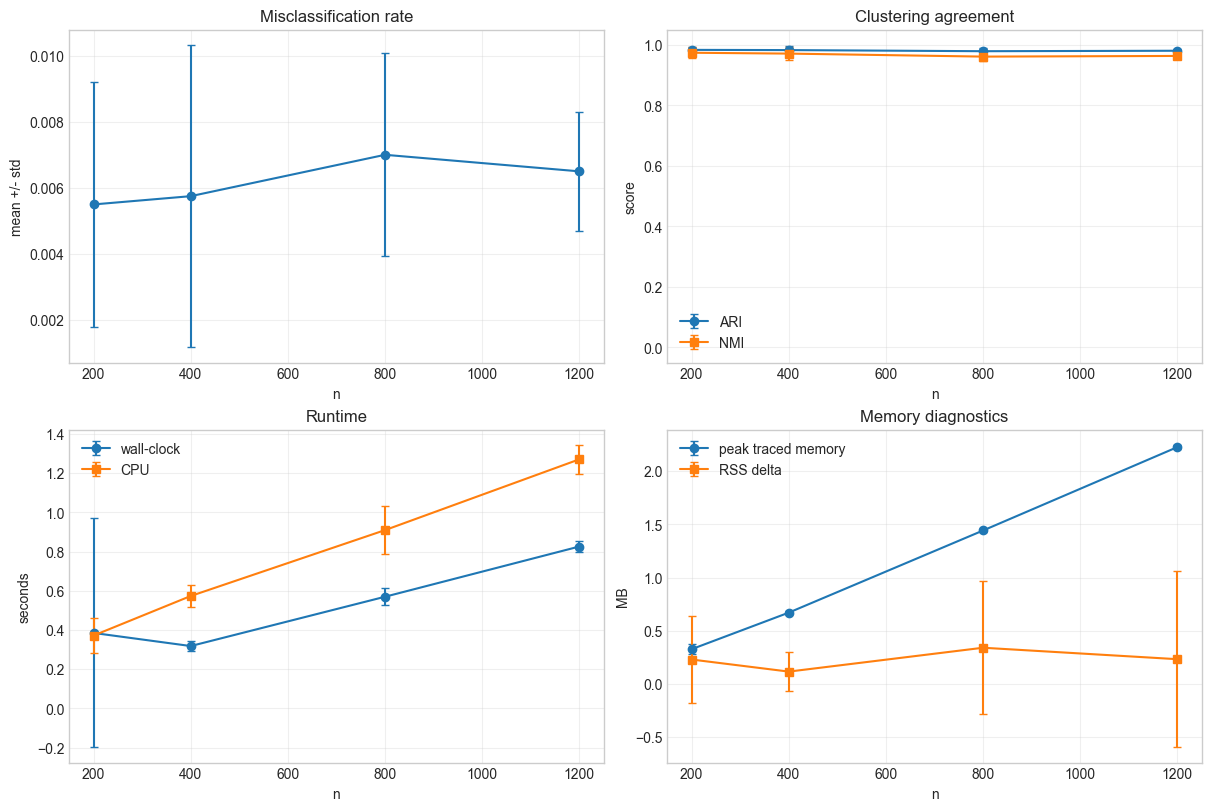

WindowsPath('c:/Users/WWindows10/Documents/github_project/python-rand-nla-research/experiments/메인 실험/results/EXP-20260425-001_nonuniform_hsbm_n_scaling_zhou_laplacian/EXP-20260425-001_nonuniform_hsbm_n_scaling_zhou_laplacian_summary.png')

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
x = summary["n"].to_numpy()

axes[0, 0].errorbar(
    x,
    summary["misclassification_mean"],
    yerr=summary["misclassification_std"].fillna(0.0),
    marker="o",
    capsize=3,
)
axes[0, 0].set_title("Misclassification rate")
axes[0, 0].set_xlabel("n")
axes[0, 0].set_ylabel("mean +/- std")
axes[0, 0].grid(alpha=0.3)

axes[0, 1].errorbar(x, summary["ari_mean"], yerr=summary["ari_std"].fillna(0.0), marker="o", capsize=3, label="ARI")
axes[0, 1].errorbar(x, summary["nmi_mean"], yerr=summary["nmi_std"].fillna(0.0), marker="s", capsize=3, label="NMI")
axes[0, 1].set_title("Clustering agreement")
axes[0, 1].set_xlabel("n")
axes[0, 1].set_ylabel("score")
axes[0, 1].set_ylim(-0.05, 1.05)
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend()

axes[1, 0].errorbar(x, summary["wall_clock_sec_mean"], yerr=summary["wall_clock_sec_std"].fillna(0.0), marker="o", capsize=3, label="wall-clock")
axes[1, 0].errorbar(x, summary["cpu_time_sec_mean"], yerr=summary["cpu_time_sec_std"].fillna(0.0), marker="s", capsize=3, label="CPU")
axes[1, 0].set_title("Runtime")
axes[1, 0].set_xlabel("n")
axes[1, 0].set_ylabel("seconds")
axes[1, 0].grid(alpha=0.3)
axes[1, 0].legend()

axes[1, 1].errorbar(
    x,
    summary["peak_traced_memory_mb_mean"],
    yerr=summary["peak_traced_memory_mb_std"].fillna(0.0),
    marker="o",
    capsize=3,
    label="peak traced memory",
)
if summary["rss_delta_mb_mean"].notna().any():
    axes[1, 1].errorbar(
        x,
        summary["rss_delta_mb_mean"],
        yerr=summary["rss_delta_mb_std"].fillna(0.0),
        marker="s",
        capsize=3,
        label="RSS delta",
    )
axes[1, 1].set_title("Memory diagnostics")
axes[1, 1].set_xlabel("n")
axes[1, 1].set_ylabel("MB")
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend()

fig_path = OUTDIR / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}_summary.png"
fig.savefig(fig_path, dpi=180, bbox_inches="tight")
plt.show()

fig_path

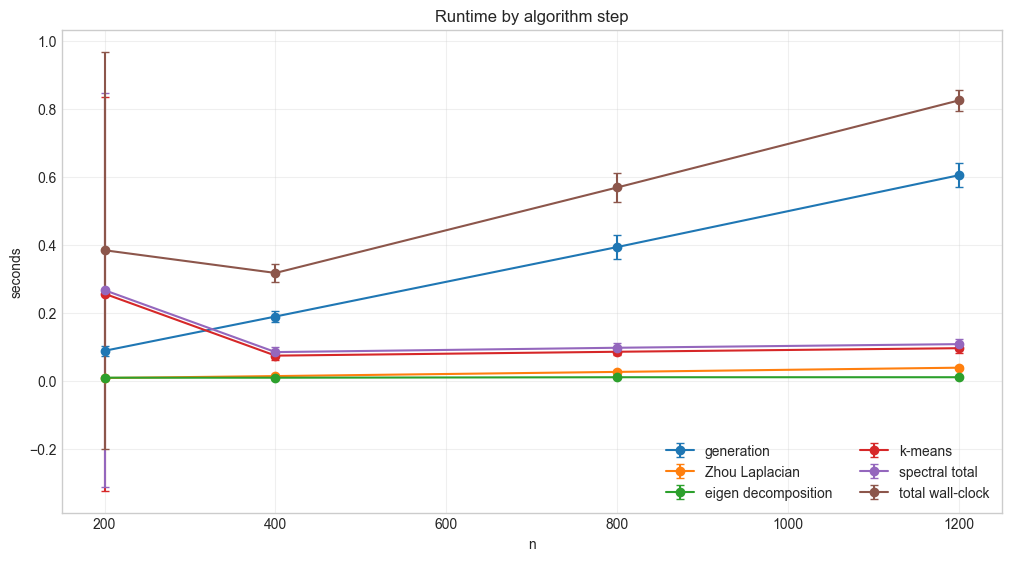

WindowsPath('c:/Users/WWindows10/Documents/github_project/python-rand-nla-research/experiments/메인 실험/results/EXP-20260425-001_nonuniform_hsbm_n_scaling_zhou_laplacian/EXP-20260425-001_nonuniform_hsbm_n_scaling_zhou_laplacian_runtime_breakdown.png')

In [10]:
x = summary["n"].to_numpy()

runtime_series = [
    ("generation_wall_sec", "generation"),
    ("zhou_laplacian_wall_sec", "Zhou Laplacian"),
    ("eigen_decomposition_wall_sec", "eigen decomposition"),
    ("kmeans_wall_sec", "k-means"),
    ("spectral_clustering_wall_sec", "spectral total"),
    ("wall_clock_sec", "total wall-clock"),
]

fig, ax = plt.subplots(figsize=(10, 5.5), constrained_layout=True)
for col, label in runtime_series:
    mean_col = f"{col}_mean"
    std_col = f"{col}_std"
    if mean_col not in summary.columns:
        continue
    ax.errorbar(
        x,
        summary[mean_col],
        yerr=summary[std_col].fillna(0.0) if std_col in summary.columns else None,
        marker="o",
        capsize=3,
        label=label,
    )

ax.set_title("Runtime by algorithm step")
ax.set_xlabel("n")
ax.set_ylabel("seconds")
ax.grid(alpha=0.3)
ax.legend(ncols=2)

runtime_breakdown_path = OUTDIR / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}_runtime_breakdown.png"
fig.savefig(runtime_breakdown_path, dpi=180, bbox_inches="tight")
plt.show()

runtime_breakdown_path

## Optional: add a larger n

Uncomment and run this cell to extend the sweep. The summary cell above will need the new frame name added to its `frames` list unless you append it manually.

In [11]:
# df_n1600 = run_n_experiment(1600)